In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('student_transactions.csv')

print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1530 entries, 0 to 1529
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           1530 non-null   object 
 1   Amount         1530 non-null   float64
 2   Category       1469 non-null   object 
 3   Merchant_Name  1530 non-null   object 
 4   Payment_Mode   1530 non-null   object 
dtypes: float64(1), object(4)
memory usage: 59.9+ KB
None


,Date,Amount,Category,Merchant_Name,Payment_Mode
0,08-08-2024,6759.50,Utilities,PG_Rent,UPI
1,24-11-2024,141.71,Entertainment,Steam,Cash
2,08-09-2024,175.70,Food,Subway,UPI
3,28-09-2024,194.71,Transport,Uber,Cash
4,21-10-2024,542.00,Education,Coursera,Card


In [16]:
import pandas as pd

# Load the dirty file
df = pd.read_csv('student_transactions.csv')

# Step 1: Fix Categories (Nulls & Case)
df['Category'] = df['Category'].fillna('Misc').str.capitalize()
df['Category'] = df['Category'].replace({'Food': 'Food & Drinks', 'Transport': 'Travel'})

# Step 2: Fix Dates (Mixed Formats)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, format='mixed')

# Step 3: Remove Duplicates
df = df.drop_duplicates()

# Step 4: Export for Power BI
df.to_csv('cleaned_student_transactions.csv', index=False)
print("File Cleaned! Download 'cleaned_student_transactions.csv' and use it in Power BI.")

File Cleaned! Download 'cleaned_student_transactions.csv' and use it in Power BI.


/tmp/ipykernel_5795/2791813186.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_data, x='Amount', y='Category', palette='viridis')


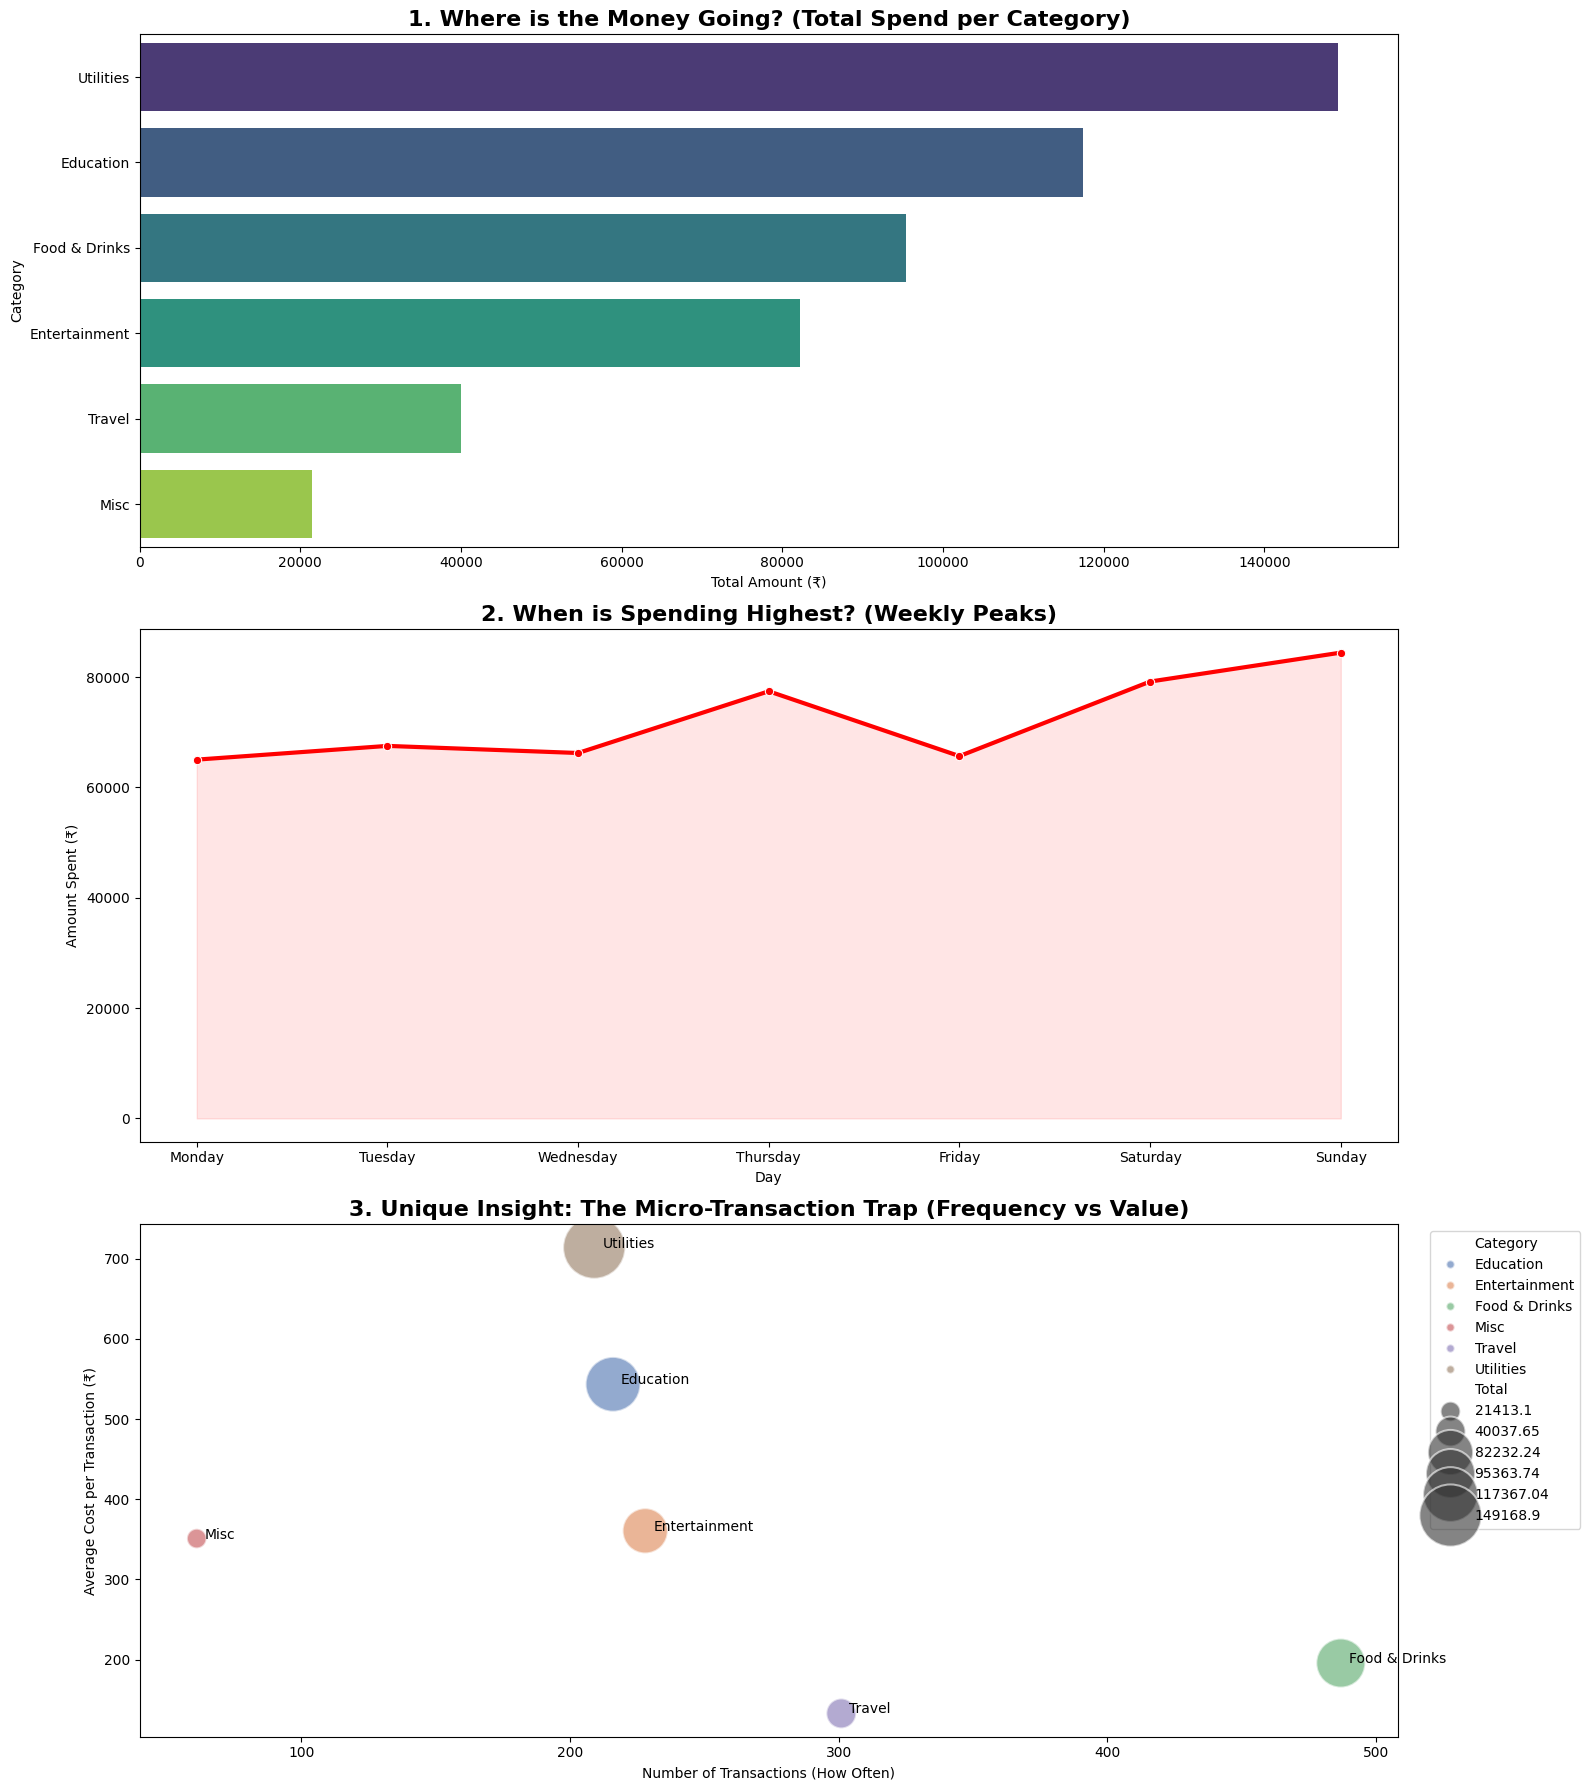

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD AND CLEAN DATA
df = pd.read_csv('student_transactions.csv')

# Handle Nulls and Case Inconsistency
df['Category'] = df['Category'].fillna('Misc').str.capitalize()
df['Category'] = df['Category'].replace({'Food': 'Food & Drinks', 'Transport': 'Travel'})

# Standardize Dates and Duplicates
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, format='mixed')
df = df.drop_duplicates()
df['Day'] = df['Date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. PREPARE DATA FOR VISUALS
# Category Totals
cat_data = df.groupby('Category')['Amount'].sum().sort_values(ascending=False).reset_index()

# Daily Totals
day_data = df.groupby('Day')['Amount'].sum().reindex(day_order).reset_index()

# Bubble Chart Data (Frequency vs Avg)
bubble_data = df.groupby('Category').agg({'Amount': ['sum', 'count', 'mean']}).reset_index()
bubble_data.columns = ['Category', 'Total', 'Frequency', 'Avg']

# 3. CREATE THE DASHBOARD (One Cell Layout)
fig = plt.figure(figsize=(16, 18))
plt.subplots_adjust(hspace=0.4)

# --- Plot 1: Spending by Category ---
plt.subplot(3, 1, 1)
sns.barplot(data=cat_data, x='Amount', y='Category', palette='viridis')
plt.title('1. Where is the Money Going? (Total Spend per Category)', fontsize=16, fontweight='bold')
plt.xlabel('Total Amount (₹)')

# --- Plot 2: Weekly Trends ---
plt.subplot(3, 1, 2)
sns.lineplot(data=day_data, x='Day', y='Amount', marker='o', color='red', linewidth=3)
plt.fill_between(day_data['Day'], day_data['Amount'], color='red', alpha=0.1)
plt.title('2. When is Spending Highest? (Weekly Peaks)', fontsize=16, fontweight='bold')
plt.ylabel('Amount Spent (₹)')

# --- Plot 3: The Micro-Transaction Trap (Unique Insight) ---
plt.subplot(3, 1, 3)
sns.scatterplot(data=bubble_data, x='Frequency', y='Avg', size='Total', hue='Category',
                sizes=(200, 2000), alpha=0.6, palette='deep')
plt.title('3. Unique Insight: The Micro-Transaction Trap (Frequency vs Value)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Transactions (How Often)')
plt.ylabel('Average Cost per Transaction (₹)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# Add category labels to the bubbles
for i in range(bubble_data.shape[0]):
    plt.text(bubble_data.Frequency[i]+3, bubble_data.Avg[i], bubble_data.Category[i], fontsize=10)

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
from google.colab import files

# 1. LOAD THE DIRTY FILE
# Make sure the name matches exactly what you uploaded
df = pd.read_csv('student_transactions.csv')

# 2. PERFORM THE CLEANING STEPS (Required by PDF)
# Fix missing categories
df['Category'] = df['Category'].fillna('Misc')

# Fix capitalization (merges 'food' and 'Food')
df['Category'] = df['Category'].str.capitalize()

# Fix inconsistent date formats (handles '-' and '/')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, format='mixed')

# Remove the 20 duplicate rows to fix budget inflation
df = df.drop_duplicates()

# 3. SAVE THE CLEANED FILE
df.to_csv('cleaned_student_transactions.csv', index=False)

# 4. AUTOMATICALLY DOWNLOAD TO YOUR COMPUTER
print("Cleaning successful! Your Power BI-ready file is downloading...")
files.download('cleaned_student_transactions.csv')

Cleaning successful! Your Power BI-ready file is downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# Assuming a monthly budget of ₹100,000 for this student
monthly_budget = 100000
avg_monthly_spend = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum().mean()

monthly_savings = monthly_budget - avg_monthly_spend
goal = 5000

if monthly_savings > 0:
    months_needed = goal / monthly_savings
    print(f"To save ₹5,000, it will take approximately {months_needed:.1f} months.")
else:
    print("Currently, spending exceeds the budget. No savings possible!")

To save ₹5,000, it will take approximately 0.3 months.
